# ProductType Classification: 3-Feature Probability Model (for the Streamlit app)

This notebook trains the model that backs the Streamlit demo: predicting `ProductType` from only `GPCBrickCode`, `UNSPSCNumber`, and `ProductDescription` — the original three-field scope.

`product_type_classification_rf_embeddings.ipynb` showed these three fields alone cap out around **63% test accuracy** (vs. 77.4% once `ProductGroup`/`ProductLine` and more text fields are added), because the two codes are frequently shared across several different `ProductType`s (93.9% of rows sit in an ambiguous code combination). Rather than force a single best guess in that ambiguous majority, this model exposes **`predict_proba`** — the fraction of the 600 trees voting for each class — so downstream users (or the Streamlit UI) can see the top few candidate `ProductType`s and how confident the model actually is, instead of a single opaque label.

Pipeline is identical to Hybrid v1: one-hot encode `GPCBrickCode`+`UNSPSCNumber`, embed `ProductDescription` with `SentenceTransformer("all-MiniLM-L6-v2")` (zero vector when missing), concatenate, train a `RandomForestClassifier`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib
import seaborn as sns


RANDOM_STATE = 42

# --- palette: one dict, referenced by role/slot instead of one variable per color ---
PALETTE = {
    "surface":     "#fcfcfb",
    "ink_primary": "#0b0b0b",
    "ink_secondary": "#52514e",
    "ink_muted":   "#898781",
    "gridline":    "#e1e0d9",
    "baseline":    "#c3c2b7",
    "categorical": ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                     "#e87ba4", "#008300", "#4a3aa7", "#e34948"],
    "sequential_blue": ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
                         "#256abf", "#184f95", "#0d366b"],
}
blue_cmap = LinearSegmentedColormap.from_list("blue_seq", PALETTE["sequential_blue"])

plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["baseline"],
    "axes.labelcolor": PALETTE["ink_secondary"],
    "text.color": PALETTE["ink_primary"],
    "xtick.color": PALETTE["ink_muted"],
    "ytick.color": PALETTE["ink_muted"],
    "grid.color": PALETTE["gridline"],
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Load data

In [17]:
DATA_PATH = "product_classified_Full.csv"
CAT_FEATURES = ["GPCBrickCode", "UNSPSCNumber"]
TEXT_FEATURE = "ProductDescription"
TARGET = "ProductType"

df = pd.read_csv(DATA_PATH)
df = df[CAT_FEATURES + [TEXT_FEATURE, TARGET]].copy()
print(df.shape)
df.head()

(10237, 4)


,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductType
0,NaN,NaN,NaN,Main Products
1,NaN,NaN,NaN,To be decided
2,NaN,NaN,NaN,To be decided
3,10005844 - Medical Devices,42301502.0,NeoNatalie is an inflatable simulator designed...,Main Products
4,10005844 - Medical Devices,42301502.0,NeoNatalie is an inflatable simulator designed...,Main Products


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10237 entries, 0 to 10236
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GPCBrickCode        8938 non-null   object 
 1   UNSPSCNumber        8759 non-null   float64
 2   ProductDescription  3912 non-null   object 
 3   ProductType         10237 non-null  object 
dtypes: float64(1), object(3)
memory usage: 320.0+ KB


In [4]:
df.isna().sum()

GPCBrickCode          1299
UNSPSCNumber          1478
ProductDescription    6325
ProductType              0
dtype: int64

In [5]:
resdf=(
    df.groupby(
        ["GPCBrickCode", "UNSPSCNumber", "ProductDescription"],
        dropna=False
    )
    .size()
    .reset_index(name="count")
)

In [6]:
resdf[resdf['count']>10].sort_values(by='count',ascending=False)

,GPCBrickCode,UNSPSCNumber,ProductDescription,count
591,10007598 - Maintenance/Repair Services,72151800.0,NaN,1453
1258,99999999 - Temporary Classification,42301502.0,NaN,1212
1728,NaN,NaN,NaN,650
1466,99999999 - Temporary Classification,NaN,SimMan 3G is a durable patient simulator creat...,250
966,99999999 - Temporary Classification,42301501.0,NaN,223
...,...,...,...,...
1084,99999999 - Temporary Classification,42301502.0,MamaNatalie birthing simulator that comes with...,12
1098,99999999 - Temporary Classification,42301502.0,Mini Anne is a low cost CPR kits which include...,12
1185,99999999 - Temporary Classification,42301502.0,SimNewB is a newborn tetherless simulator co-c...,12
283,10001138 - Computer Software (Non Games),55111513.0,NaN,11


In [7]:
mask = df[["GPCBrickCode", "UNSPSCNumber", "ProductDescription"]].isna().all(axis=1)

df[mask]

,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductType
0,NaN,NaN,NaN,Main Products
1,NaN,NaN,NaN,To be decided
2,NaN,NaN,NaN,To be decided
12,NaN,NaN,NaN,Service Parts
22,NaN,NaN,NaN,Main Products
...,...,...,...,...
9827,NaN,NaN,NaN,Service Agreement
9828,NaN,NaN,NaN,Service Return to Laerdal
9829,NaN,NaN,NaN,Service Return to Laerdal
9846,NaN,NaN,NaN,Software Products


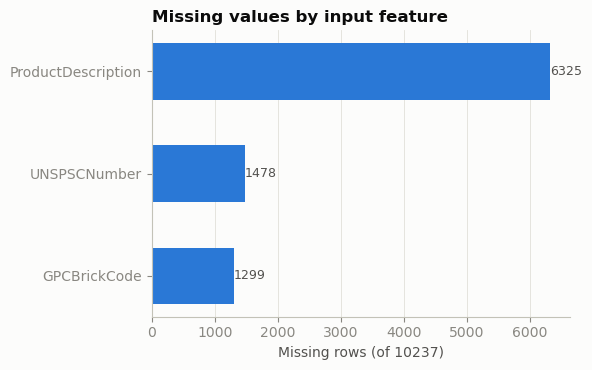

In [18]:
TEXT_FEATURES = ["ProductDescription"]

missing = df[CAT_FEATURES + TEXT_FEATURES].isna().sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.barh(missing.index[::-1], missing.values[::-1], color=PALETTE["categorical"][0], height=0.55)
ax.set_xlabel("Missing rows (of %d)" % len(df))
ax.set_title("Missing values by input feature", loc="left", fontweight="bold", color=PALETTE["ink_primary"])
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
for b, v in zip(bars, missing.values[::-1]):
    ax.text(v + 1, b.get_y() + b.get_height()/2, str(v), va="center", color=PALETTE["ink_secondary"], fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
df.dropna(subset=["GPCBrickCode", "UNSPSCNumber","ProductDescription"], how="all",inplace=True)

In [9]:
df.isna().sum()

GPCBrickCode           649
UNSPSCNumber           828
ProductDescription    5675
ProductType              0
dtype: int64

In [10]:
df.head()

,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductType
3,10005844 - Medical Devices,42301502.0,NeoNatalie is an inflatable simulator designed...,Main Products
4,10005844 - Medical Devices,42301502.0,NeoNatalie is an inflatable simulator designed...,Main Products
5,99999999 - Temporary Classification,42301502.0,Bariatric complete suit in dark skin tone,Main Products
6,99999999 - Temporary Classification,42301502.0,Bariatric complete suit in light skin tone,Main Products
7,99999999 - Temporary Classification,42301502.0,Bariatric complete suit in medium skin tone,Main Products


In [11]:
product_df=df["ProductType"].value_counts().reset_index(name="count").sort_values(by='count')

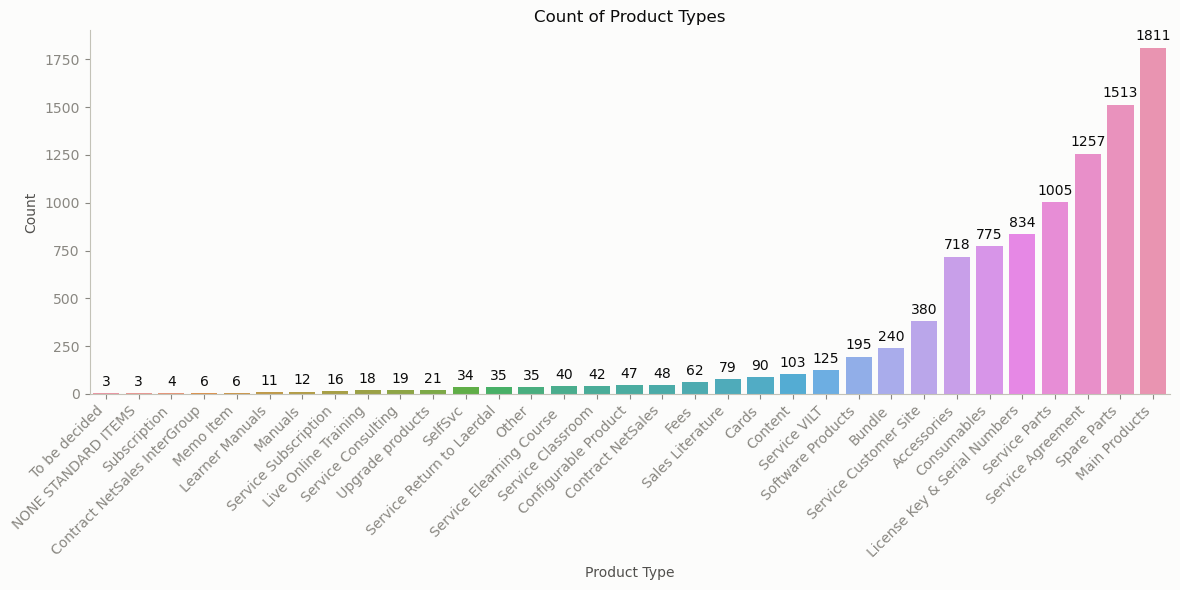

In [12]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=product_df,
    x="ProductType",
    y="count"
)

# Add count labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Count of Product Types")
plt.xlabel("Product Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Unique (GPCBrickCode, UNSPSCNumber) combinations: 311
Weighted purity (codes alone -> ProductType): 58.9%
Rows in an ambiguous combination (>1 ProductType): 93.5%


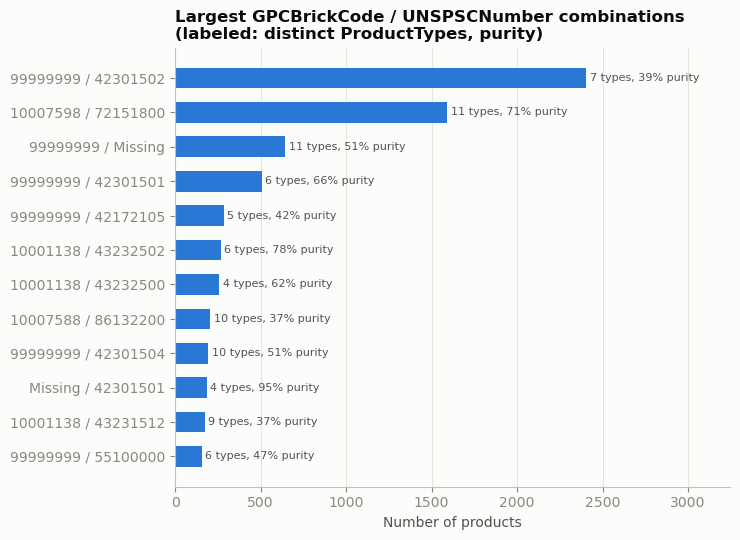

In [13]:
g = df.groupby(["GPCBrickCode", "UNSPSCNumber"], dropna=False)[TARGET]
combo_stats = pd.DataFrame({
    "size": g.size(),
    "n_types": g.nunique(),
    "purity": g.agg(lambda s: s.value_counts().iloc[0] / len(s)),
})

weighted_purity = (combo_stats["purity"] * combo_stats["size"]).sum() / combo_stats["size"].sum()
ambiguous = combo_stats[combo_stats["n_types"] > 1]
ambiguous_row_share = ambiguous["size"].sum() / combo_stats["size"].sum()

print(f"Unique (GPCBrickCode, UNSPSCNumber) combinations: {len(combo_stats)}")
print(f"Weighted purity (codes alone -> ProductType): {weighted_purity:.1%}")
print(f"Rows in an ambiguous combination (>1 ProductType): {ambiguous_row_share:.1%}")

top = combo_stats.sort_values("size", ascending=False).head(12).iloc[::-1]


def short_label(gpc, unspsc):
    gpc_short = str(gpc).split(" - ")[0] if pd.notna(gpc) else "Missing"
    unspsc_short = str(int(unspsc)) if pd.notna(unspsc) else "Missing"
    return f"{gpc_short} / {unspsc_short}"


labels = [short_label(gpc, unspsc) for gpc, unspsc in top.index]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
bars = ax.barh(labels, top["size"], color=PALETTE["categorical"][0], height=0.6)
ax.set_xlabel("Number of products")
ax.set_title("Largest GPCBrickCode / UNSPSCNumber combinations\n(labeled: distinct ProductTypes, purity)",
             loc="left", fontweight="bold", color=PALETTE["ink_primary"])
ax.grid(axis="x", linewidth=0.6)
ax.set_axisbelow(True)
for b, (n_types, purity) in zip(bars, zip(top["n_types"], top["purity"])):
    ax.text(b.get_width() + 20, b.get_y() + b.get_height() / 2,
            f"{n_types} types, {purity:.0%} purity",
            va="center", color=PALETTE["ink_secondary"], fontsize=8)
ax.set_xlim(0, top["size"].max() * 1.35)
plt.tight_layout()
plt.show()

## Fold rare ProductType classes into `Other`
Same rule as the other notebooks: classes with fewer than 10 samples are folded into `Other` rather than dropped.

In [7]:
MIN_CLASS_COUNT = 10
type_counts = df[TARGET].value_counts()
rare_types = type_counts[type_counts < MIN_CLASS_COUNT].index.tolist()
print(f"Folding {len(rare_types)} ProductType classes with < {MIN_CLASS_COUNT} samples into 'Other':")
print(rare_types)

df[TARGET] = df[TARGET].where(~df[TARGET].isin(rare_types), "Other")
print(f"\nClasses: {type_counts.shape[0]} -> {df[TARGET].nunique()}")

Folding 5 ProductType classes with < 10 samples into 'Other':
['Memo Item', 'Contract NetSales InterGroup', 'Subscription', 'NONE STANDARD ITEMS', 'To be decided']

Classes: 33 -> 28


## Train / test split — on raw data, before any fitting
Split first, fit nothing on the full dataset. `OneHotEncoder` and any embedding statistics should only ever see the training rows; the test rows must stay unseen until evaluation, otherwise the "test" accuracy is partly measuring information that leaked in from the encoder having seen those exact category values already.

In [8]:
df["GPCBrickCode"] = df["GPCBrickCode"].fillna("Missing")
df["UNSPSCNumber"] = df["UNSPSCNumber"].fillna(-1).astype(int).astype(str)

df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET]
)
print(f"Train: {len(df_train)}  Test: {len(df_test)}")
print(f"Classes in train: {df_train[TARGET].nunique()}  Classes in test: {df_test[TARGET].nunique()} (of {df[TARGET].nunique()} total)")

Train: 7669  Test: 1918
Classes in train: 28  Classes in test: 28 (of 28 total)


## Encode `GPCBrickCode` + `UNSPSCNumber` as one-hot
Fit only on `df_train`. `handle_unknown="ignore"` means any category that only ever appears in the test set (never seen during training) gets encoded as all-zeros for that feature — the model just falls back to whatever other signal is available for that row, rather than erroring.

In [9]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
cat_train = ohe.fit_transform(df_train[CAT_FEATURES])
cat_test = ohe.transform(df_test[CAT_FEATURES])
n_gpc = len(ohe.categories_[0])
n_unspsc = len(ohe.categories_[1])

print(f"GPCBrickCode categories (from train only): {n_gpc}, UNSPSCNumber categories: {n_unspsc}")
print("Train one-hot shape:", cat_train.shape, " Test one-hot shape:", cat_test.shape)

GPCBrickCode categories (from train only): 8, UNSPSCNumber categories: 194
Train one-hot shape: (7669, 202)  Test one-hot shape: (1918, 202)


## Embed `ProductDescription`
Zero vector for rows with no description. `SentenceTransformer` is a frozen pretrained model — it isn't fit to this data at all — so encoding train and test separately here is about keeping the pipeline symmetric with the split above, not about preventing leakage (there's no statistic being learned from the text either way).

In [10]:
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBED_MODEL_NAME)
embed_dim = embedder.get_sentence_embedding_dimension()


def embed_text_column(series):
    text = series.fillna("")
    has_text = text.str.strip() != ""
    embeddings = np.zeros((len(series), embed_dim), dtype=np.float32)
    non_empty_idx = np.where(has_text.to_numpy())[0]
    if len(non_empty_idx):
        embeddings[non_empty_idx] = embedder.encode(
            text[has_text].tolist(),
            batch_size=64,
            show_progress_bar=True,
            convert_to_numpy=True,
        )
    return embeddings, has_text.sum()


text_train, n_train_with_desc = embed_text_column(df_train[TEXT_FEATURE])
text_test, n_test_with_desc = embed_text_column(df_test[TEXT_FEATURE])

print(f"Train rows with a real ProductDescription: {n_train_with_desc} / {len(df_train)}")
print(f"Test rows with a real ProductDescription: {n_test_with_desc} / {len(df_test)}")
print("Train embedding shape:", text_train.shape, " Test embedding shape:", text_test.shape)

/opt/anaconda3/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Train rows with a real ProductDescription: 3114 / 7669
Test rows with a real ProductDescription: 797 / 1918
Train embedding shape: (7669, 384)  Test embedding shape: (1918, 384)


## Combine into train/test feature matrices
No split here — `X_train`/`X_test` are built by concatenating the already-separately-fit encodings.

In [11]:
X_train = np.hstack([cat_train, text_train])
X_test = np.hstack([cat_test, text_test])
y_train = df_train[TARGET]
y_test = df_test[TARGET]

print("Train feature matrix shape:", X_train.shape)
print("Test feature matrix shape:", X_test.shape)

Train feature matrix shape: (7669, 586)
Test feature matrix shape: (1918, 586)


## Train Random Forest

In [12]:
model = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=1,
    class_weight=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=600, n_jobs=-1, random_state=42)

## Test set evaluation

In [13]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.3f}")
print()
print(classification_report(y_test, y_pred, zero_division=0))

Test accuracy: 0.639

                              precision    recall  f1-score   support

                 Accessories       0.73      0.49      0.59       144
                      Bundle       0.38      0.17      0.23        48
                       Cards       1.00      0.50      0.67        18
        Configurable Product       0.54      0.78      0.64         9
                 Consumables       0.70      0.47      0.56       155
                     Content       0.78      0.67      0.72        21
           Contract NetSales       0.00      0.00      0.00        10
                        Fees       1.00      0.08      0.15        12
             Learner Manuals       0.00      0.00      0.00         2
License Key & Serial Numbers       0.70      0.95      0.81       167
        Live Online Training       0.00      0.00      0.00         4
               Main Products       0.77      0.70      0.74       362
                     Manuals       0.00      0.00      0.00        

## Export the test set for manual testing in the Streamlit app
`df_test` holds the raw, human-readable rows the model never saw during training — `GPCBrickCode`/`UNSPSCNumber` are already in the exact string form the encoder expects (e.g. `"Missing"` for nulls, integer-strings for codes), so a row from this file can be pasted directly into the app's `GPCBrickCode`/`UNSPSCNumber`/`ProductDescription` inputs and the app's prediction compared against the real `ProductType` in the `ProductType` column.

In [14]:
TEST_SET_PATH = "product_type_test_set.csv"
df_test[CAT_FEATURES + [TEXT_FEATURE, TARGET]].to_csv(TEST_SET_PATH, index=False)
print(f"Saved {len(df_test)} held-out rows to {TEST_SET_PATH}")
df_test[CAT_FEATURES + [TEXT_FEATURE, TARGET]].head()

Saved 1918 held-out rows to product_type_test_set.csv


,GPCBrickCode,UNSPSCNumber,ProductDescription,ProductType
8874,10007598 - Maintenance/Repair Services,72151800,NaN,Service Agreement
7373,99999999 - Temporary Classification,42301501,NaN,Consumables
793,99999999 - Temporary Classification,42301504,The SonoSim® Ultrasound Training Solution is a...,Spare Parts
1976,99999999 - Temporary Classification,42301502,Spare Part chest skin for Resusci Baby,Spare Parts
3047,10007588 - Educational Services,72151800,NaN,Service VILT


## Top-k predictions with probability
Instead of a single label, `predict_proba` gives a distribution over all classes. For each row below, the top 3 candidate `ProductType`s are shown with their probability — this is what the Streamlit dropdown will surface.

In [15]:
def top_k_from_proba(proba_row, classes, k=3):
    order = np.argsort(proba_row)[::-1][:k]
    return [(classes[i], proba_row[i]) for i in order]


proba_test = model.predict_proba(X_test)
classes = model.classes_

sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=8, replace=False)
for i in sample_idx:
    actual = y_test.to_numpy()[i]
    top3 = top_k_from_proba(proba_test[i], classes, k=3)
    top3_str = ", ".join(f"{t} ({p:.0%})" for t, p in top3)
    marker = "OK" if top3[0][0] == actual else ("~~" if actual in [t for t, _ in top3] else "XX")
    print(f"[{marker}] actual={actual:<30} top3: {top3_str}")

[~~] actual=Service Parts                  top3: Spare Parts (40%), Service Parts (18%), Main Products (18%)
[OK] actual=Service Agreement              top3: Service Agreement (72%), Service Customer Site (12%), Bundle (9%)
[~~] actual=Spare Parts                    top3: Accessories (48%), Main Products (30%), Spare Parts (10%)
[~~] actual=Main Products                  top3: Spare Parts (40%), Service Parts (18%), Main Products (18%)
[OK] actual=Main Products                  top3: Main Products (100%), Upgrade products (0%), Spare Parts (0%)
[OK] actual=License Key & Serial Numbers   top3: License Key & Serial Numbers (90%), Main Products (1%), Software Products (1%)
[OK] actual=Accessories                    top3: Accessories (86%), Main Products (5%), Spare Parts (2%)
[OK] actual=Service Agreement              top3: Service Agreement (72%), Service Customer Site (12%), Bundle (9%)


## Does looking at the top-3 (not just top-1) help?
"Top-k accuracy" — is the correct `ProductType` anywhere in the model's top 3 guesses? This quantifies how much the probability view recovers versus a single hard prediction.

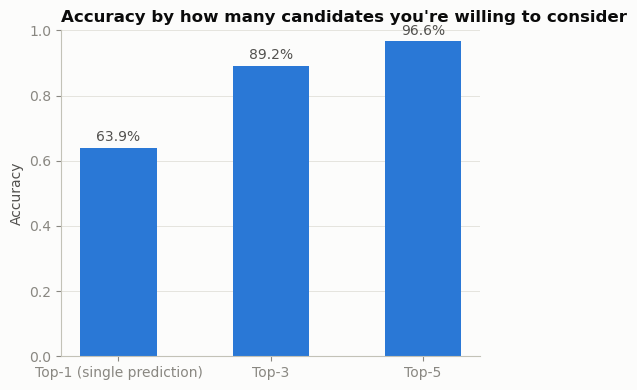

In [16]:
def top_k_accuracy(proba, classes, y_true, k):
    class_to_idx = {c: i for i, c in enumerate(classes)}
    true_idx = y_true.map(class_to_idx).to_numpy()
    top_k_idx = np.argsort(proba, axis=1)[:, -k:]
    return np.mean([t in row for t, row in zip(true_idx, top_k_idx)])


topk_acc = pd.Series({
    "Top-1 (single prediction)": top_k_accuracy(proba_test, classes, y_test, 1),
    "Top-3": top_k_accuracy(proba_test, classes, y_test, 3),
    "Top-5": top_k_accuracy(proba_test, classes, y_test, 5),
})

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(topk_acc.index, topk_acc.values, color=PALETTE["categorical"][0], width=0.5)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Accuracy by how many candidates you're willing to consider",
             loc="left", fontweight="bold", color=PALETTE["ink_primary"])
ax.grid(axis="y", linewidth=0.6)
ax.set_axisbelow(True)
for b, v in zip(bars, topk_acc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.1%}",
            ha="center", color=PALETTE["ink_secondary"], fontsize=10)
plt.tight_layout()
plt.show()

In [17]:
df[df['UNSPSCNumber'] == '43231512']['ProductType'].value_counts(normalize=True)

ProductType
License Key & Serial Numbers    0.444444
Software Products               0.176245
Bundle                          0.149425
Main Products                   0.068966
Fees                            0.065134
Configurable Product            0.049808
Service Agreement               0.026820
Content                         0.011494
Service Elearning Course        0.003831
Other                           0.003831
Name: proportion, dtype: float64

## Reusable inference function
This is the function the Streamlit app calls: raw `GPCBrickCode`/`UNSPSCNumber`/`ProductDescription` in, ranked `(ProductType, probability)` list out.

In [18]:
def predict_topk(gpc_brick_code, unspsc_number, product_description, k=3):
    gpc_val = gpc_brick_code if gpc_brick_code else "Missing"
    try:
        unspsc_val = str(int(unspsc_number))
    except (TypeError, ValueError):
        unspsc_val = "-1"

    row_cat = ohe.transform(pd.DataFrame([[gpc_val, unspsc_val]], columns=CAT_FEATURES))

    text = (product_description or "").strip()
    if text:
        row_text = embedder.encode([text], convert_to_numpy=True)
    else:
        row_text = np.zeros((1, embed_dim), dtype=np.float32)

    row_X = np.hstack([row_cat, row_text])
    proba_row = model.predict_proba(row_X)[0]
    return top_k_from_proba(proba_row, model.classes_, k=k)


# Example: a row from the data, called through the same path the Streamlit app will use
example = df.iloc[3]
print("Input:", example["GPCBrickCode"], "|", example["UNSPSCNumber"], "|", example[TEXT_FEATURE][:60], "...")
print("Predicted top-3:", predict_topk(example["GPCBrickCode"], example["UNSPSCNumber"], example[TEXT_FEATURE]))

Input: 99999999 - Temporary Classification | 42301502 | Bariatric complete suit in light skin tone ...
Predicted top-3: [('Main Products', 0.8858177339901478), ('Accessories', 0.026433189655172416), ('Spare Parts', 0.02567508210180624)]


In [19]:
X_test

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.05846175,
         0.08120421, -0.02519997],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., -0.00318159,
        -0.02079442,  0.03432976]])

## Save model artifacts for the Streamlit app
Three things are needed at inference time: the trained `RandomForestClassifier`, the fitted `OneHotEncoder` (to reproduce the same one-hot columns), and the raw category lists (so the app's dropdowns only offer values the model was actually trained on). `SentenceTransformer("all-MiniLM-L6-v2")` is re-downloaded/cached at runtime rather than saved.

In [20]:
joblib.dump(model, "product_type_rf_3feat_model.joblib")
joblib.dump(ohe, "product_type_rf_3feat_ohe.joblib")
joblib.dump({"embed_model_name": EMBED_MODEL_NAME, "embed_dim": embed_dim}, "product_type_rf_3feat_meta.joblib")
print("Saved product_type_rf_3feat_model.joblib, product_type_rf_3feat_ohe.joblib, product_type_rf_3feat_meta.joblib")

Saved product_type_rf_3feat_model.joblib, product_type_rf_3feat_ohe.joblib, product_type_rf_3feat_meta.joblib
